In [29]:
from tensorflow.keras.preprocessing.text import one_hot

In [30]:
### sentences
sent=[  'the glass of milk',
     'the glass of juice',
     'the cup of tea',
    'I am a good boy',
     'I am a good developer',
     'understand the meaning of words',
     'your videos are good',]

In [31]:
sent

['the glass of milk',
 'the glass of juice',
 'the cup of tea',
 'I am a good boy',
 'I am a good developer',
 'understand the meaning of words',
 'your videos are good']

In [32]:
# Define the vocabulory size
voc_size = 10000

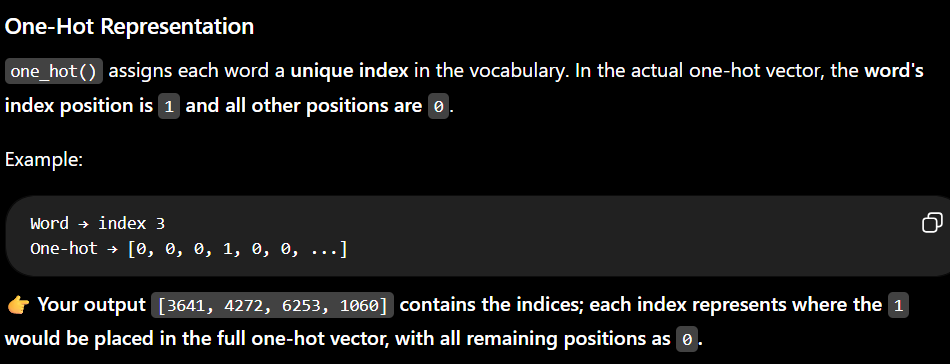

In [33]:
# One Hot Representation
one_hot_repr = [one_hot(words, voc_size) for words in sent]

In [34]:
one_hot_repr

[[3641, 4272, 6253, 1060],
 [3641, 4272, 6253, 6567],
 [3641, 1175, 6253, 6290],
 [147, 9171, 8673, 2185, 9985],
 [147, 9171, 8673, 2185, 2817],
 [7354, 3641, 7360, 6253, 3456],
 [84, 7190, 6070, 2185]]

So; we cannot use OHE technique vectors in embedding layer as it leads to OVERFITTING due to sparse matrix [Single 1 rest all are zeros] in each word's vector dimension and also takes a lot of space un-necessarily

Instead, we will use this above One hot representaion where the words are converted into those index values where the value is "1" from their One hot Encoding (OHE) technique vector  by OHE vectorization technique.

In [35]:
# Word Embedding Representation
from tensorflow.keras.layers import Embedding
# from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential

In [36]:
import numpy as np

In [39]:
sent_length = 8
embedded_docs = pad_sequences(one_hot_repr, padding='pre', maxlen=sent_length)

In [56]:
embedded_docs

array([[   0,    0,    0,    0, 3641, 4272, 6253, 1060],
       [   0,    0,    0,    0, 3641, 4272, 6253, 6567],
       [   0,    0,    0,    0, 3641, 1175, 6253, 6290],
       [   0,    0,    0,  147, 9171, 8673, 2185, 9985],
       [   0,    0,    0,  147, 9171, 8673, 2185, 2817],
       [   0,    0,    0, 7354, 3641, 7360, 6253, 3456],
       [   0,    0,    0,    0,   84, 7190, 6070, 2185]])

In [41]:
pad_sequences(one_hot_repr, padding='post', maxlen=sent_length)

array([[3641, 4272, 6253, 1060,    0,    0,    0,    0],
       [3641, 4272, 6253, 6567,    0,    0,    0,    0],
       [3641, 1175, 6253, 6290,    0,    0,    0,    0],
       [ 147, 9171, 8673, 2185, 9985,    0,    0,    0],
       [ 147, 9171, 8673, 2185, 2817,    0,    0,    0],
       [7354, 3641, 7360, 6253, 3456,    0,    0,    0],
       [  84, 7190, 6070, 2185,    0,    0,    0,    0]])

In [42]:
# feature representation of size:10
dim = 10

In [43]:
model = Sequential()
model.add(Embedding(voc_size,dim,input_length=sent_length))
model.compile("adam", "mse")

In [44]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 8, 10)             100000    
                                                                 
Total params: 100000 (390.62 KB)
Trainable params: 100000 (390.62 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


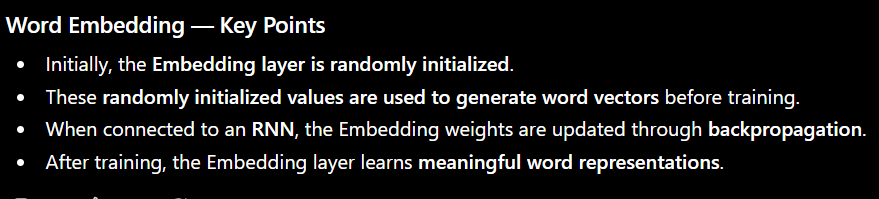

In [45]:
model.predict(embedded_docs)

1/1 [==============================] - 0s 382ms/step


array([[[ 3.61276753e-02, -3.16733271e-02, -4.27406915e-02,
          1.07438341e-02, -4.64284085e-02, -2.73731351e-02,
          3.47522832e-02, -1.27291307e-02,  3.81046869e-02,
         -8.20397213e-03],
        [ 3.61276753e-02, -3.16733271e-02, -4.27406915e-02,
          1.07438341e-02, -4.64284085e-02, -2.73731351e-02,
          3.47522832e-02, -1.27291307e-02,  3.81046869e-02,
         -8.20397213e-03],
        [ 3.61276753e-02, -3.16733271e-02, -4.27406915e-02,
          1.07438341e-02, -4.64284085e-02, -2.73731351e-02,
          3.47522832e-02, -1.27291307e-02,  3.81046869e-02,
         -8.20397213e-03],
        [ 3.61276753e-02, -3.16733271e-02, -4.27406915e-02,
          1.07438341e-02, -4.64284085e-02, -2.73731351e-02,
          3.47522832e-02, -1.27291307e-02,  3.81046869e-02,
         -8.20397213e-03],
        [ 1.62332915e-02,  4.79425117e-03,  3.93424891e-02,
         -7.05868006e-03, -2.07914468e-02, -1.76673755e-02,
          3.05809118e-02, -4.52688001e-02,  8.653234

In [46]:
embedded_docs[0]

array([   0,    0,    0,    0, 3641, 4272, 6253, 1060])

In [57]:
model.predict([embedded_docs[0]])

1/1 [==============================] - 0s 94ms/step


array([[ 0.03612768, -0.03167333, -0.04274069,  0.01074383, -0.04642841,
        -0.02737314,  0.03475228, -0.01272913,  0.03810469, -0.00820397],
       [ 0.03612768, -0.03167333, -0.04274069,  0.01074383, -0.04642841,
        -0.02737314,  0.03475228, -0.01272913,  0.03810469, -0.00820397],
       [ 0.03612768, -0.03167333, -0.04274069,  0.01074383, -0.04642841,
        -0.02737314,  0.03475228, -0.01272913,  0.03810469, -0.00820397],
       [ 0.03612768, -0.03167333, -0.04274069,  0.01074383, -0.04642841,
        -0.02737314,  0.03475228, -0.01272913,  0.03810469, -0.00820397],
       [ 0.01623329,  0.00479425,  0.03934249, -0.00705868, -0.02079145,
        -0.01766738,  0.03058091, -0.0452688 ,  0.00865323, -0.01718465],
       [ 0.04742965, -0.03079417, -0.01916442,  0.00423006,  0.01161865,
         0.04566664,  0.01861959,  0.00374204, -0.0389218 ,  0.04306788],
       [-0.02177454, -0.01181204,  0.04560794, -0.01956921, -0.04569906,
         0.03689666,  0.04461542, -0.01443567